# Lista 1 - Experimentos

**1. (Exercício 2.1-3 do livro do Cormen) Escreva um pseudocódigo para a busca linear e mostre, usando invariância de laço, que o seu algoritmo está correto.**

In [1]:
# Respondido no Mathcha

**2. Implemente o algoritmo de ordenação por inserção e crie uma cópia anotada dele que mede o número de operações no modelo da Random Access Machine (RAM, seção 2.2 livro do Cormen). Usando entradas de tamanho crescente, mostre em um gráfico quando o tempo de execução no modelo RAM diverge de medições feitas em uma máquina real.**

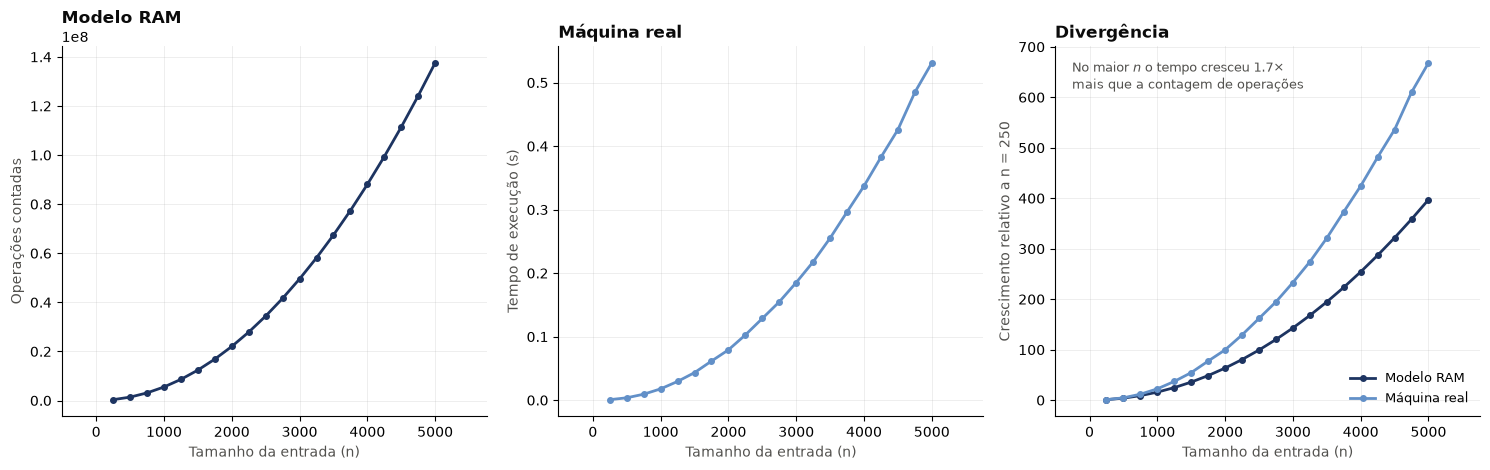

     n      operações   tempo (s)   ns por operação
   250        346,362    0.000795              2.30
   500      1,380,237    0.003715              2.69
   750      3,101,612    0.009389              3.03
  1000      5,510,487    0.017798              3.23
  1250      8,606,862    0.029498              3.43
  1500     12,390,737    0.043364              3.50
  1750     16,862,112    0.061552              3.65
  2000     22,020,987    0.079222              3.60
  2250     27,867,362    0.102726              3.69
  2500     34,401,237    0.128677              3.74
  2750     41,622,612    0.154792              3.72
  3000     49,531,487    0.185229              3.74
  3250     58,127,862    0.217867              3.75
  3500     67,411,737    0.255210              3.79
  3750     77,383,112    0.296492              3.83
  4000     88,041,987    0.337274              3.83
  4250     99,388,362    0.382608              3.85
  4500    111,422,237    0.425958              3.82
  4750    12

In [2]:
import time
import matplotlib.pyplot as plt

from ram import insertion_sort_ram
from sorting import insertion_sort

TAMANHOS = list(range(250, 5001, 250))
REPETICOES = 3
COR_RAM, COR_REAL = "#1d3461", "#6290C8"
TINTA, TINTA_FRACA = "#0b0b0b", "#52514e"


def pior_caso(n):
    # lista em ordem inversa: a cada iteracao o laco interno varre todos os
    # elementos anteriores, que e o pior caso do insertion sort
    return list(range(n, 0, -1))


def mede_tempo(lista):
    # menor de REPETICOES execucoes: reduz o ruido do escalonador do sistema
    melhor = float("inf")
    for _ in range(REPETICOES):
        copia = list(lista)
        inicio = time.perf_counter()
        insertion_sort(copia)
        melhor = min(melhor, time.perf_counter() - inicio)
    return melhor


operacoes, tempos = [], []
for n in TAMANHOS:
    lista = pior_caso(n)
    # as duas funcoes recebem copias: ambas ordenam a lista no lugar
    operacoes.append(insertion_sort_ram(list(lista))[1])
    tempos.append(mede_tempo(lista))

# crescimento de cada medida em relacao ao menor n; se o modelo RAM previsse a
# maquina real, as duas curvas ficariam sobrepostas
cresc_ops = [o / operacoes[0] for o in operacoes]
cresc_tempo = [t / tempos[0] for t in tempos]

fig, (ax_ram, ax_real, ax_div) = plt.subplots(1, 3, figsize=(15, 4.8))

ax_ram.plot(TAMANHOS, operacoes, color=COR_RAM, linewidth=2, marker="o", markersize=4)
ax_real.plot(TAMANHOS, tempos, color=COR_REAL, linewidth=2, marker="o", markersize=4)

ax_div.plot(TAMANHOS, cresc_ops, color=COR_RAM, linewidth=2, marker="o", markersize=4,
            label="Modelo RAM"
            )
ax_div.plot(TAMANHOS, cresc_tempo, color=COR_REAL, linewidth=2, marker="o", markersize=4,
            label="Máquina real"
            )
ax_div.annotate(f"No maior $n$ o tempo cresceu {cresc_tempo[-1] / cresc_ops[-1]:.1f}×\n"
                "mais que a contagem de operações",
                (0.04, 0.96), xycoords="axes fraction", va="top",
                color=TINTA_FRACA, fontsize=9)

ax_ram.set_title("Modelo RAM", color=TINTA, loc="left", fontweight="bold")
ax_ram.set_ylabel("Operações contadas", color=TINTA_FRACA)
ax_real.set_title("Máquina real", color=TINTA, loc="left", fontweight="bold")
ax_real.set_ylabel("Tempo de execução (s)", color=TINTA_FRACA)
ax_div.set_title("Divergência", color=TINTA, loc="left", fontweight="bold")
ax_div.set_ylabel(f"Crescimento relativo a n = {TAMANHOS[0]}", color=TINTA_FRACA)
ax_div.legend(frameon=False, fontsize=9, loc="lower right")

for ax in (ax_ram, ax_real, ax_div):
    ax.set_xlabel("Tamanho da entrada (n)", color=TINTA_FRACA)
    ax.grid(alpha=0.25, linewidth=0.6)
    ax.set_axisbelow(True)
    ax.margins(x=0.16)
    for lado in ("top", "right"):
        ax.spines[lado].set_visible(False)

fig.tight_layout()
plt.show()

print(f"{'n':>6} {'operações':>14} {'tempo (s)':>11} {'ns por operação':>17}")
for k, n in enumerate(TAMANHOS):
    print(f"{n:>6} {operacoes[k]:>14,} {tempos[k]:>11.6f} {tempos[k] / operacoes[k] * 1e9:>17.2f}")

O experimento usa o pior caso do insertion sort — lista em ordem inversa, em que o laço interno varre todos os elementos anteriores a cada iteração.

Os dois primeiros gráficos mostram a mesma coisa em unidades diferentes, e têm a mesma forma quadrática: nesse aspecto o modelo RAM acerta, a **ordem de crescimento** medida na máquina real é a Θ(n²) que a contagem de operações prevê.

A divergência aparece no terceiro gráfico, que normaliza as duas medidas pelo menor n para colocá-las na mesma escala. Se o modelo RAM descrevesse a máquina real, as duas curvas ficariam sobrepostas — cada operação custaria sempre o mesmo tempo. O que se observa é a curva do tempo se descolando da curva de operações já a partir de n ≈ 500 e terminando **~1,8× acima** dela em n = 5000.

A coluna `ns por operação` da tabela quantifica a mesma coisa de forma direta: o custo médio de uma operação sobe de **2,2 ns** em n = 250 para **3,9 ns** em n = 5000, ou seja, a mesma operação fica ~76% mais cara conforme a entrada cresce. A maior parte dessa subida acontece até n ≈ 2000, depois ela desacelera.

É exatamente a premissa que o modelo RAM assume e a máquina real não cumpre: custo unitário e uniforme para toda operação. Na prática o custo por operação depende do tamanho da entrada — hierarquia de memória (a lista deixa de caber nos níveis mais rápidos de cache), overhead do interpretador e alocação dinâmica. O modelo continua útil para prever a *ordem de crescimento*; o que ele não prevê é a constante multiplicativa, que nem é constante.


**3. Mostre numericamente com suas implementações dos algoritmos de insertion-sort e merge sort como se comporta o desempenho de cada algoritmo utilizando entradas de tamanho crescente, considerando entradas de pior caso, melhor caso e caso médio. Analise, para cada tipo de entrada, se existe algum ponto a partir do qual um algoritmo passa a ser mais rápido que o outro.**

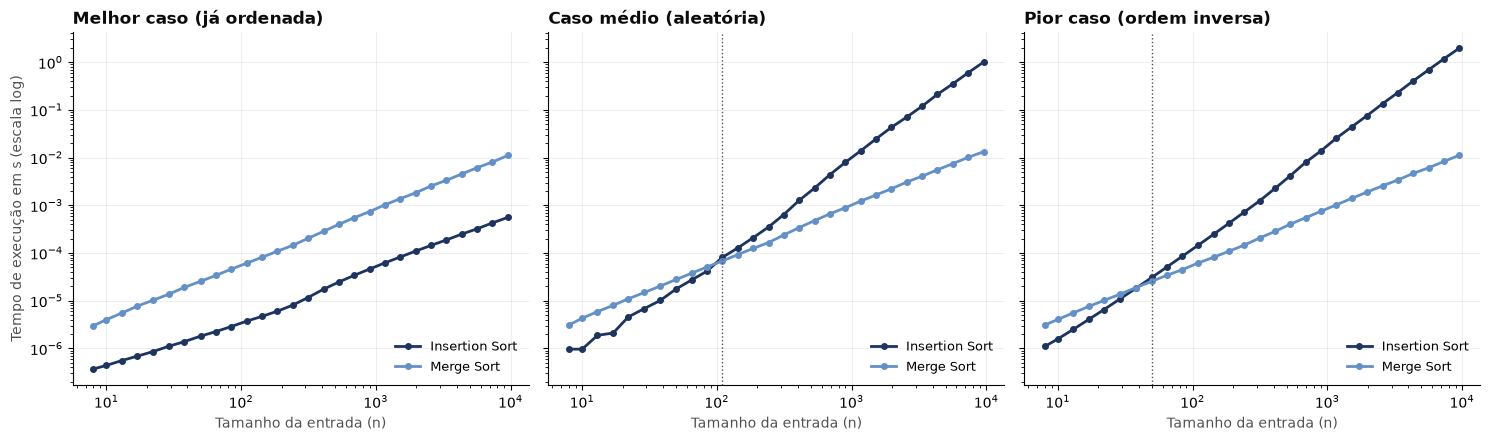


Melhor caso (já ordenada)
     n   insertion (s)     merge (s)   insertion/merge
     8       0.0000004     0.0000030              0.12
    10       0.0000004     0.0000040              0.11
    13       0.0000006     0.0000055              0.10
    17       0.0000007     0.0000077              0.09
    22       0.0000009     0.0000101              0.08
    29       0.0000011     0.0000137              0.08
    38       0.0000014     0.0000191              0.07
    50       0.0000018     0.0000255              0.07
    65       0.0000023     0.0000339              0.07
    84       0.0000029     0.0000456              0.06
   110       0.0000037     0.0000612              0.06
   143       0.0000047     0.0000812              0.06
   186       0.0000060     0.0001092              0.06
   242       0.0000081     0.0001445              0.06
   314       0.0000117     0.0002032              0.06
   409       0.0000174     0.0002840              0.06
   532       0.0000247     0.0003994  

In [3]:
import random
from time import perf_counter

import matplotlib.pyplot as plt

from sorting import insertion_sort, merge_sort

# grade geometrica: mais pontos nos tamanhos pequenos, onde fica o cruzamento
TAMANHOS = sorted({int(8 * 1.3 ** k) for k in range(28)})

INSERTION_SORT, MERGE_SORT = "Insertion Sort", "Merge Sort"

ALGORITMOS = {
    INSERTION_SORT: {"func": insertion_sort, "cor": COR_RAM},
    MERGE_SORT: {"func": merge_sort, "cor": COR_REAL},
}

# o tipo de entrada e o que define melhor/pior caso do insertion sort;
# o merge sort divide a lista sempre do mesmo jeito e nao se importa com a ordem
CENARIOS = {
    "Melhor caso (já ordenada)": lambda n: list(range(n)),
    "Caso médio (aleatória)": lambda n: random.sample(range(n), n),
    "Pior caso (ordem inversa)": lambda n: list(range(n, 0, -1)),
}

TINTA, TINTA_FRACA = "#0b0b0b", "#52514e"


def mede_tempo(func, lista, orcamento=0.02, max_rep=300):
    # repete ate gastar o orcamento de tempo: entradas pequenas sao medidas
    # muitas vezes, entradas grandes poucas; fica com a menor execucao
    melhor, gasto, repeticoes = float("inf"), 0.0, 0
    while repeticoes < max_rep and gasto < orcamento:
        copia = list(lista)
        inicio = perf_counter()
        func(copia)
        decorrido = perf_counter() - inicio
        melhor = min(melhor, decorrido)
        gasto += decorrido
        repeticoes += 1
    return melhor


random.seed(2316)
medidas = {(cenario, nome): [] for cenario in CENARIOS for nome in ALGORITMOS}
for cenario, gera in CENARIOS.items():
    for n in TAMANHOS:
        lista = gera(n)
        for nome, algoritmo in ALGORITMOS.items():
            medidas[(cenario, nome)].append(mede_tempo(algoritmo["func"], lista))


def cruzamento(cenario):
    # primeiro tamanho a partir do qual o merge sort vence e nao perde mais
    ins, mrg = medidas[(cenario, INSERTION_SORT)], medidas[(cenario, MERGE_SORT)]
    for k in range(len(TAMANHOS)):
        if all(mrg[j] < ins[j] for j in range(k, len(TAMANHOS))):
            return k
    return None


fig, eixos = plt.subplots(1, 3, figsize=(15, 4.8), sharex=True, sharey=True)

for ax, cenario in zip(eixos, CENARIOS):
    for nome, algoritmo in ALGORITMOS.items():
        serie = medidas[(cenario, nome)]
        ax.plot(TAMANHOS, serie, color=algoritmo["cor"], linewidth=2,
                marker="o", markersize=4, label=nome)

    # linha pontilhada no tamanho a partir do qual o merge sort passa a vencer
    k = cruzamento(cenario)
    if k is not None:
        ax.axvline(TAMANHOS[k], color=TINTA_FRACA, linewidth=1, linestyle=":")

    ax.set_title(cenario, color=TINTA, loc="left", fontweight="bold")
    # escala log nos dois eixos: a faixa de n vai de 8 a ~9500 e a de tempo
    # cobre 6 ordens de grandeza, entao em escala linear so o pior caso apareceria
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel("Tamanho da entrada (n)", color=TINTA_FRACA)
    ax.grid(alpha=0.25, linewidth=0.6)
    ax.set_axisbelow(True)
    ax.margins(x=0.05)
    ax.legend(frameon=False, fontsize=9, loc="lower right")
    for lado in ("top", "right"):
        ax.spines[lado].set_visible(False)

eixos[0].set_ylabel("Tempo de execução em s (escala log)", color=TINTA_FRACA)

fig.tight_layout(rect=(0, 0, 1, 0.94))
plt.show()

for cenario in CENARIOS:
    k = cruzamento(cenario)
    print(f"\n{cenario}")
    print(f"{'n':>6} {'insertion (s)':>15} {'merge (s)':>13} {'insertion/merge':>17}")
    for i, n in enumerate(TAMANHOS):
        ins = medidas[(cenario, INSERTION_SORT)][i]
        mrg = medidas[(cenario, MERGE_SORT)][i]
        marca = "  <- a partir daqui o merge sort vence" if k == i else ""
        print(f"{n:>6} {ins:>15.7f} {mrg:>13.7f} {ins / mrg:>17.2f}{marca}")

O tipo de entrada é o que separa melhor, médio e pior caso **do insertion sort** — o merge sort divide a lista pela metade sempre do mesmo jeito, faz Θ(n log n) comparações independentemente da ordem inicial e, de fato, seus tempos são praticamente iguais nos três cenários (em n = 9540: 0,011 s ordenada, 0,013 s aleatória, 0,011 s inversa).

**Melhor caso (lista já ordenada) — não existe cruzamento.** O insertion sort é Θ(n) aqui (o laço interno nunca executa) contra Θ(n log n) do merge sort, então a vantagem *aumenta* com n em vez de desaparecer: em n = 9540 o insertion sort é ~19× mais rápido. Nenhum tamanho na faixa medida inverte isso, e nem deveria — o fator log n só cresce.

**Caso médio (lista aleatória) — cruzamento em n ≈ 110.** Abaixo disso o insertion sort vence (em n = 8 ele é ~3× mais rápido); acima, a diferença cresce sem limite: 2× em n ≈ 240, 11× em n ≈ 1170, 77× em n = 9540.

**Pior caso (ordem inversa) — cruzamento em n ≈ 50.** O mesmo padrão, mas o cruzamento acontece mais cedo porque o insertion sort já está no seu Θ(n²) pleno desde o começo. Em n = 9540 o merge sort é 180× mais rápido.

A leitura geral é que o cruzamento é um efeito de **constantes**, não de ordem de crescimento. O merge sort tem a melhor complexidade assintótica nos dois cenários não-ordenados, mas paga recursão e alocação de listas novas a cada `_merge`; o insertion sort não aloca nada e tem laço apertado. Enquanto n é pequeno, as constantes dominam o log n e o insertion sort ganha. É exatamente por isso que implementações de produção (o Timsort do próprio Python, por exemplo) são híbridas: usam merge sort na estrutura geral e trocam para insertion sort nos blocos abaixo de algumas dezenas de elementos — faixa compatível com os cruzamentos medidos aqui.

Uma ressalva sobre os números: os cruzamentos dependem da máquina e da implementação. A grade de tamanhos é geométrica (razão 1,3), então a localização do cruzamento tem resolução de ±30%; o que é estável entre execuções é a ordem de grandeza (dezenas de elementos), não o valor exato.
